# 🎨 Seaborn Fundamentals
**Analytics Club — Learners' Space 2026 | Phase 1**

Seaborn is built on top of Matplotlib and makes statistical plots look good
with very little code. It's tightly integrated with Pandas — you just pass
in your DataFrame and tell it which columns to use.

My take: use Seaborn as the starting point, then use Matplotlib to fine-tune.

---

## 1. Setup and the Tips Dataset

Seaborn ships with several built-in datasets that are perfect for learning.
`tips` is a classic — restaurant bill and tip data with several categorical variables.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('Seaborn version:', sns.__version__)

# Load built-in dataset
tips = sns.load_dataset('tips')
print('\nTips dataset shape:', tips.shape)
print('\nColumns:', tips.columns.tolist())
print('\nFirst 5 rows:')
print(tips.head())

Seaborn version: 0.12.2

Tips dataset shape: (244, 7)

Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

## 2. Distribution Plots — `histplot`

Before doing anything else with a dataset, I look at the distribution of
the key variables. Adding `kde=True` overlays a smooth density curve.

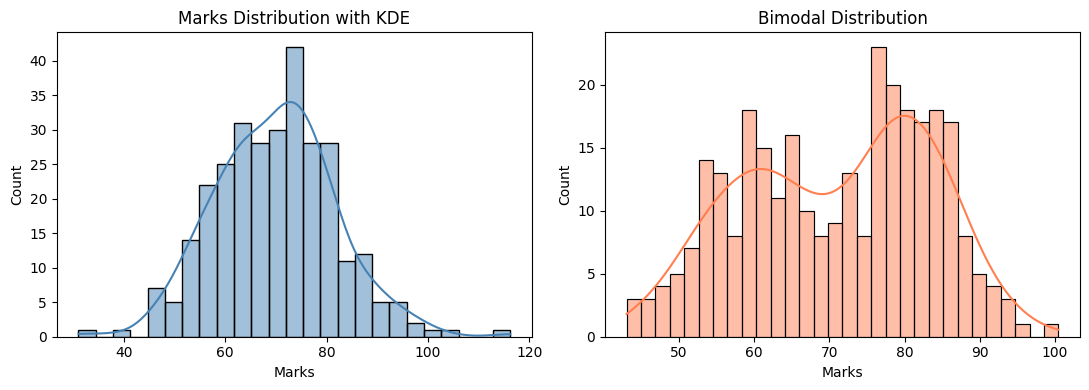

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Normal distribution
data1 = np.random.normal(70, 12, 300)
sns.histplot(data1, bins=25, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Marks Distribution with KDE')
axes[0].set_xlabel('Marks')

# Bimodal — two overlapping groups
data2 = np.concatenate([np.random.normal(60, 8, 150),
                         np.random.normal(82, 6, 150)])
sns.histplot(data2, bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Bimodal Distribution')
axes[1].set_xlabel('Marks')

plt.tight_layout()
plt.show()

## 3. Box Plots and Violin Plots

Both show the distribution of a numeric variable across categories.
- **Box plot** shows the five-number summary (min, Q1, median, Q3, max) + outliers
- **Violin plot** shows the full distribution shape (a mirrored KDE)

I prefer violin plots — they reveal bimodal or skewed distributions that box plots hide.

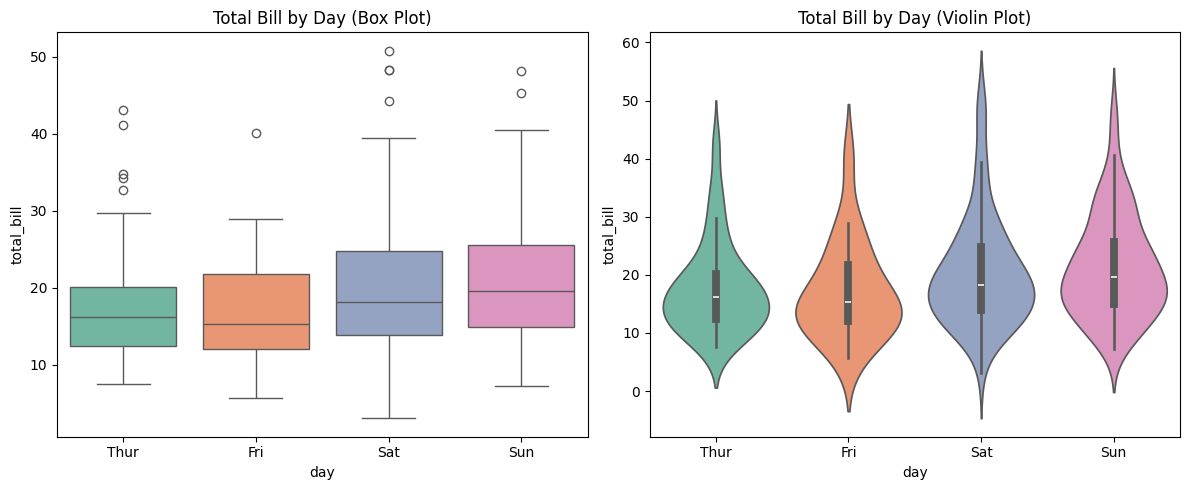

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=tips, x='day', y='total_bill',
            hue='day', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Total Bill by Day (Box Plot)')

sns.violinplot(data=tips, x='day', y='total_bill',
               hue='day', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Total Bill by Day (Violin Plot)')

plt.tight_layout()
plt.show()

## 4. Scatter Plot with `hue`, `style`, and `size`

Seaborn's `scatterplot` is much more powerful than Matplotlib's — you can encode
up to four variables in one plot using x, y, hue (color), style (marker shape),
and size (marker size).

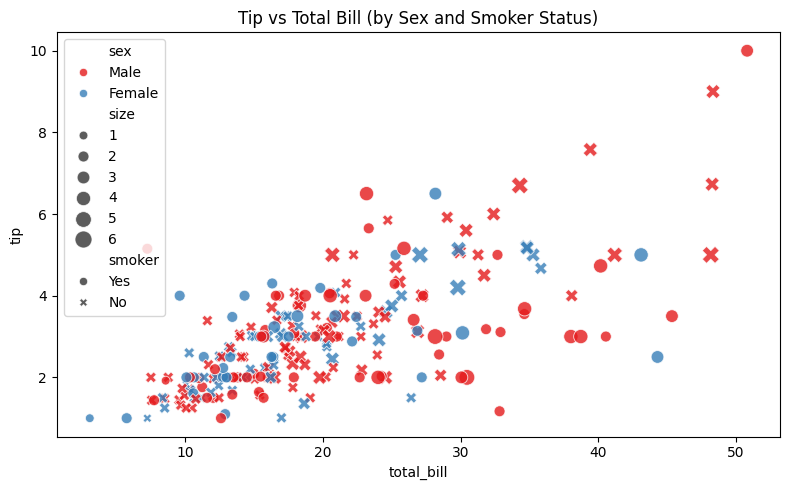

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=tips,
    x='total_bill', y='tip',
    hue='sex',       # color by gender
    style='smoker',  # marker shape by smoker status
    size='size',     # point size by party size
    sizes=(40, 150),
    palette='Set1',
    alpha=0.8,
    ax=ax
)
ax.set_title('Tip vs Total Bill (by Sex and Smoker Status)')

plt.tight_layout()
plt.show()

## 5. Heatmaps — Correlation Matrices

Heatmaps are perfect for showing a matrix of values — most commonly a
correlation matrix. The `annot=True` argument prints the values inside each cell.

Correlation matrix:
            total_bill    tip   size
total_bill       1.000  0.676  0.599
tip              0.676  1.000  0.489
size             0.599  0.489  1.000

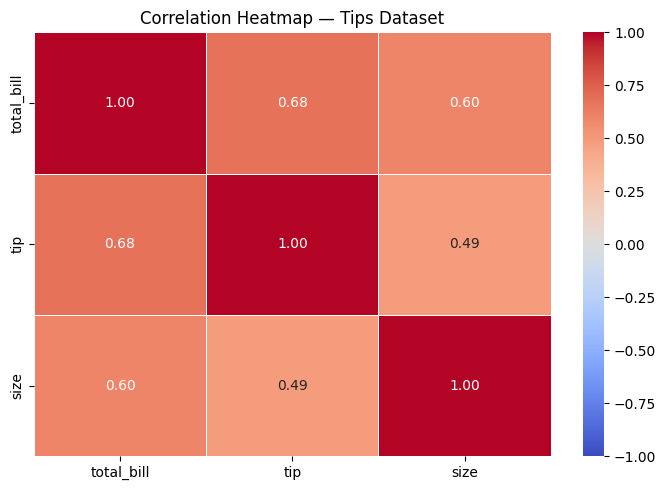

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

corr = tips[['total_bill', 'tip', 'size']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title('Correlation Heatmap — Tips Dataset')

plt.tight_layout()
plt.show()

print('\nCorrelation matrix:')
print(corr.round(3))

## 6. Bar Plots and Count Plots

- `barplot` shows the mean (or other statistic) of a numeric variable per category
- `countplot` just counts the occurrences of each category value

The `errorbar='sd'` parameter in `barplot` adds standard deviation error bars.

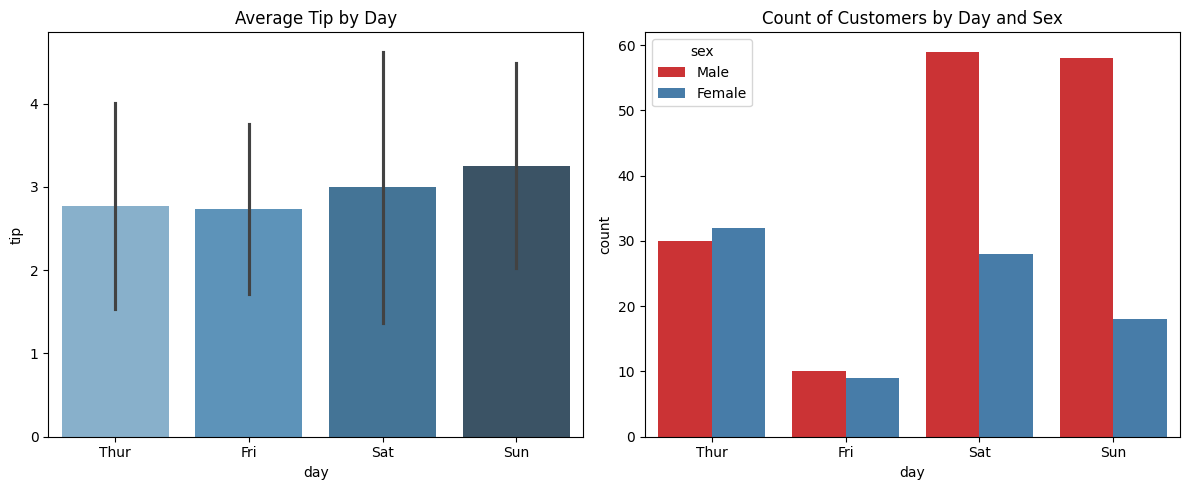

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset('tips')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average tip per day with SD error bars
sns.barplot(data=tips, x='day', y='tip',
            estimator=np.mean, errorbar='sd',
            hue='day', palette='Blues_d', legend=False,
            ax=axes[0])
axes[0].set_title('Average Tip by Day')

# Count of customers by day and sex
sns.countplot(data=tips, x='day', hue='sex', palette='Set1', ax=axes[1])
axes[1].set_title('Count of Customers by Day and Sex')

plt.tight_layout()
plt.show()

## 7. Pair Plots — Exploring All Relationships at Once

`pairplot` creates a grid showing the relationship between every pair of
numeric columns. Diagonal shows the distribution of each variable.
This is the fastest way to get an overview of a dataset.

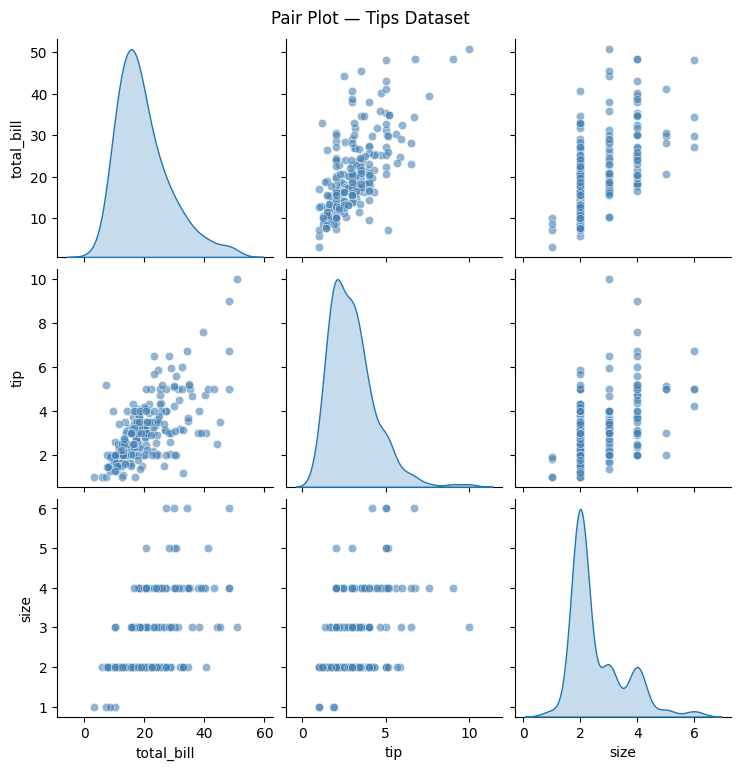

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

g = sns.pairplot(
    tips[['total_bill', 'tip', 'size']],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'color': 'steelblue'}
)
g.fig.suptitle('Pair Plot — Tips Dataset', y=1.02)

plt.tight_layout()
plt.show()

## 8. Themes and Styling

Seaborn has five built-in themes: `darkgrid`, `whitegrid`, `dark`, `white`, `ticks`.
I personally use `whitegrid` most of the time — it looks clean and professional.

In [ ]:
import seaborn as sns
print('Available themes:', ['darkgrid','whitegrid','dark','white','ticks'])

# Set theme globally
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)

# Reset to default
# sns.reset_defaults()

# Color palettes
print('\nUseful palettes:')
for p in ['Set1','Set2','Set3','pastel','muted','deep','colorblind','Blues_d','Reds_d']:
    print(f'  {p}')

Available themes: ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

Useful palettes:
  Set1
  Set2
  Set3
  pastel
  muted
  deep
  colorblind
  Blues_d
  Reds_d

## 9. Seaborn vs Matplotlib — When to Use What

| Situation | Use |
|-----------|-----|
| Quick statistical exploration | Seaborn |
| Correlation/distribution overview | Seaborn (`pairplot`, `heatmap`) |
| Category comparisons | Seaborn (`barplot`, `boxplot`) |
| Custom layout, subplots | Matplotlib |
| Fine control over every element | Matplotlib |
| Publication-quality figures | Both (Seaborn for base, Matplotlib for polish) |

The best approach: create your plot with Seaborn, then use Matplotlib's `ax` methods
to add custom elements like annotations, arrows, or custom tick labels.

```python
fig, ax = plt.subplots()
sns.boxplot(data=df, x='group', y='value', ax=ax)  # seaborn for the plot
ax.set_title('My Title')   # matplotlib for customisation
ax.set_ylim(0, 100)
```

## 10. Practice Exercise

Load the `iris` or `penguins` dataset from Seaborn and create:
1. A histogram of the numeric columns
2. A boxplot comparing species
3. A heatmap of the correlation matrix
4. A pairplot coloured by species

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset('penguins').dropna()
print('Penguins dataset:')
print(penguins.head())
print('\nShape:', penguins.shape)
print('Species:', penguins['species'].unique())

Penguins dataset:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    Male
1  Adelie  Torgersen            39.5           17.4              186.0       3800.0  Female
2  Adelie  Torgersen            40.3           18.0              195.0       3250.0  Female
4  Adelie  Torgersen            36.7           19.3              193.0       3450.0  Female
5  Adelie  Torgersen            39.3           20.6              190.0       3650.0    Male

Shape: (333, 7)
Species: ['Adelie' 'Gentoo' 'Chinstrap']